In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/dell/ML-Learning/datasets/online_retail_II_features.csv")
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

# reuse the same summary logic from ML-004
sales = df[~df["is_cancelled"]]

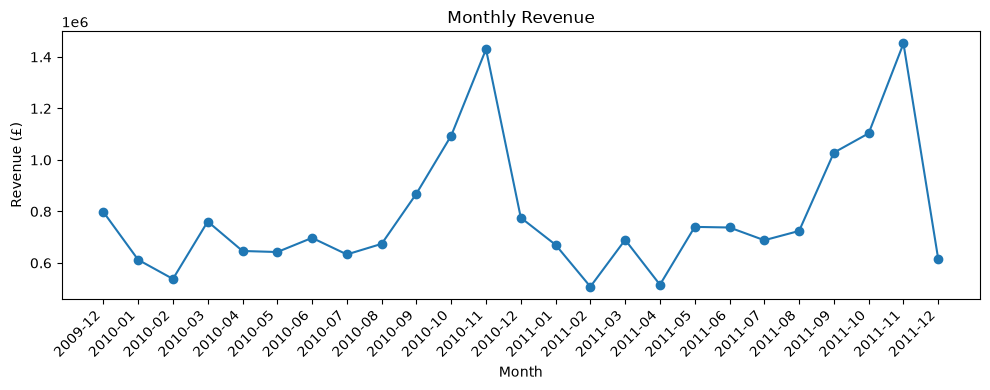

In [3]:
monthly_revenue = sales.groupby("year_month")["total_price"].sum()

plt.figure(figsize=(10, 4))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

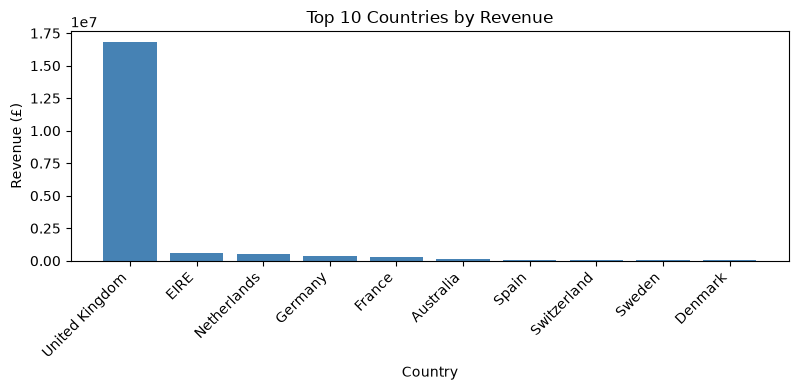

In [4]:
top_countries = sales.groupby("country")["total_price"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
plt.bar(top_countries.index, top_countries.values, color="steelblue")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

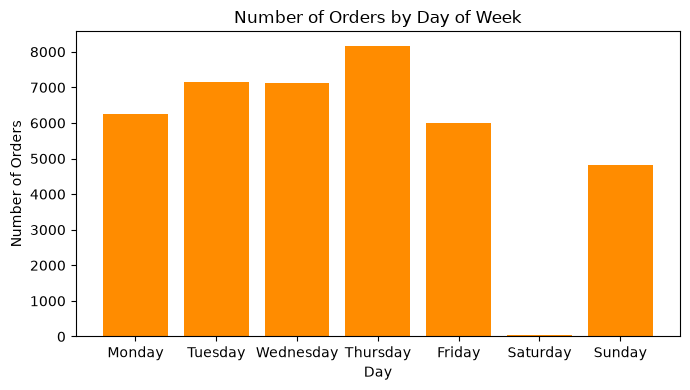

In [5]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
orders_by_day = sales.groupby("day_of_week")["invoice"].nunique().reindex(day_order)

plt.figure(figsize=(7, 4))
plt.bar(orders_by_day.index, orders_by_day.values, color="darkorange")
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

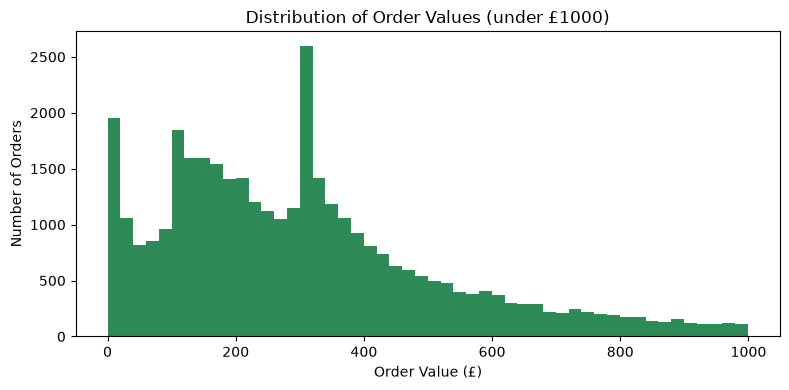

In [6]:
invoice_values = sales.drop_duplicates(subset="invoice")["invoice_total_value"]

plt.figure(figsize=(8, 4))
plt.hist(invoice_values[invoice_values < 1000], bins=50, color="seagreen")  # capped for readability
plt.title("Distribution of Order Values (under £1000)")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

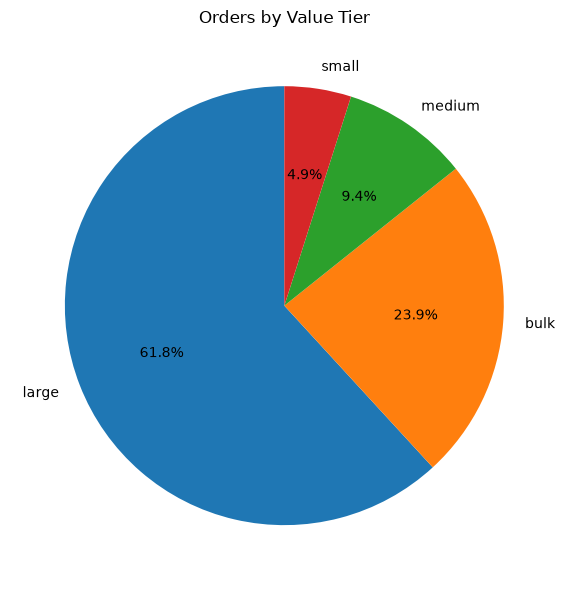

In [7]:
tier_counts = sales.drop_duplicates(subset="invoice")["order_value_tier"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(tier_counts.values, labels=tier_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Orders by Value Tier")
plt.tight_layout()
plt.show()